In [ ]:
!pip install pandas scikit-learn yellowbrick

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [ ]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data

--2026-05-12 20:34:25--  https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘letter-recognition.data.1’

letter-recognition.     [  <=>               ] 695.86K  2.26MB/s    in 0.3s    

2026-05-12 20:34:26 (2.26 MB/s) - ‘letter-recognition.data.1’ saved [712565]



In [ ]:
dataset = pd.read_csv("letter-recognition.data", header=None)

In [ ]:
X = dataset.iloc[:, 1:17]

Y = dataset.iloc[:, 0].values.ravel()

In [ ]:
X_train, X_validation, Y_train, Y_validation = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_validation = scaler.transform(X_validation)

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 100),
    max_iter=300,
    activation='relu',
    solver='adam',
    random_state=42
)

In [ ]:
mlp.fit(X_train, Y_train)

MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=300, random_state=42)

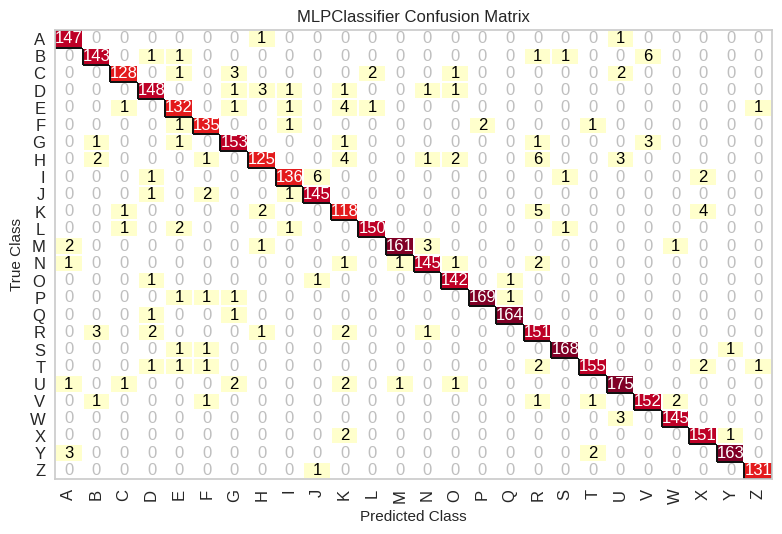

<Axes: title={'center': 'MLPClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [ ]:
from yellowbrick.classifier import ConfusionMatrix

classes = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

cm = ConfusionMatrix(mlp, classes=classes)

cm.fit(X_train, Y_train)

cm.score(X_validation, Y_validation)

cm.show()

In [ ]:
predictions = mlp.predict(X_validation)

print(predictions)

['X' 'L' 'A' ... 'Q' 'Y' 'Y']


In [ ]:
print("Accuracy:", accuracy_score(Y_validation, predictions))

Accuracy: 0.958
